# Step 3B: inspection of eigenvector sign patterns

In [1]:
%load_ext autoreload
%autoreload 2 

data_folder = "../data/"

import os
import numpy as np
import pandas as pd

# ----------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import plotting_utils as pu
from matplotlib.colors import TwoSlopeNorm
import matplotlib as mpl
# ----------------------------------------


# ----------------------------------------
from tqdm.notebook import tqdm  # progress bar 
from deeptime.clustering import KMeans
#import networkx as nx # graph visualization of MSM microstates and macrostates model
# ----------------------------------------


# ----------------------------------------
from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM
# ----------------------------------------

---
#### Reloading reduced data

In [2]:
tica_lag = 100 # lag time for TICA in frames, 1000 frames = 200 nanoseconds


tica_dim_distances = 5
tica_dim_dihedrals = 7
pca_dim_distances = 5
pca_dim_dihedrals = 5


tica_dihedrals = np.load(f"../intermediate_outputs/dimred/tica_lag_{tica_lag}_dim_{tica_dim_dihedrals}_dihedrals.npy")
pca_dihedrals = np.load(f"../intermediate_outputs/dimred/pca_dim_{pca_dim_dihedrals}_dihedrals.npy")
tica_distances = np.load(f"../intermediate_outputs/dimred/tica_lag_{tica_lag}_dim_{tica_dim_distances}_distances.npy")
pca_distances = np.load(f"../intermediate_outputs/dimred/pca_dim_{pca_dim_distances}_distances.npy")


trajectories = [tica_distances, pca_distances, tica_dihedrals, pca_dihedrals]
trajectories_labels = ["tica_distances", "pca_distances", "tica_dihedrals", "pca_dihedrals"]


total_time_micros = 305
time_step_micros =  total_time_micros / 1526041 #/ distances.shape[0]
time_step_nanos = time_step_micros * 10**3
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds
one_microsecond_in_frames = int(1 / time_step_micros)
print("One microsecond in frames", one_microsecond_in_frames) # 5000 frames


print("tICA lag (ns): ", tica_lag * time_step_nanos)

Time step (microseconds) 0.00019986356854108112
Time step (nanoseconds) 0.19986356854108112
Time step (picoseconds) 199.86356854108112
One microsecond in frames 5003
tICA lag (ns):  19.986356854108113


Estimate MSMs at selected parameters

In [3]:
MSM_LAG_NS = 50
MSM_LAG_FRAMES = int(MSM_LAG_NS / time_step_nanos) # 200 ns
print("MSM lag time in frames:", MSM_LAG_FRAMES)
N_CLUSTERS = 50
tce = TransitionCountEstimator(lagtime=MSM_LAG_FRAMES, count_mode="sliding-effective")

MSM lag time in frames: 250


In [4]:
msm_dict = {}

#cluster_centers_dict = {} # cluster idx to microstate idx
micro_trajectory_dict = {} # traj -> micro traj
#clean_micro_trajectory_dict = {} # traj -> micro traj

for i, name in enumerate(trajectories_labels):
    data = np.load(f"../intermediate_outputs/kmeans_plusplus/{N_CLUSTERS}clusters_{name}.npz")
    dtraj = data["traj"].copy()


    C = tce.fit(dtraj).fetch_model()
    submodel = C.submodel_largest(directed=True)

    micro_trajectory_dict[name] = submodel.transform_discrete_trajectories_to_submodel(data["traj"])
    #assigned_frames = micro_trajectory_dict[name] != -1
    #active_population = np.sum(assigned_frames) / len(micro_trajectory_dict[name])
    #print(f"Active population for {name}: {active_population:.4f}")

    #np.save(f"../intermediate_outputs/microstate_trajs/{n_clusters}clusters_{MSM_LAG_FRAMES}lag_{name}_submodel.npy", micro_trajectory_dict[name])

    #clean_micro_trajectory_dict[name] = pu.clean_assignments(micro_trajectory_dict[name], max_dist= 100)

    msm = MaximumLikelihoodMSM(reversible = True).fit(submodel).fetch_model()
    msm_dict[name] = msm

---

## Spectral analysis of the microstate model

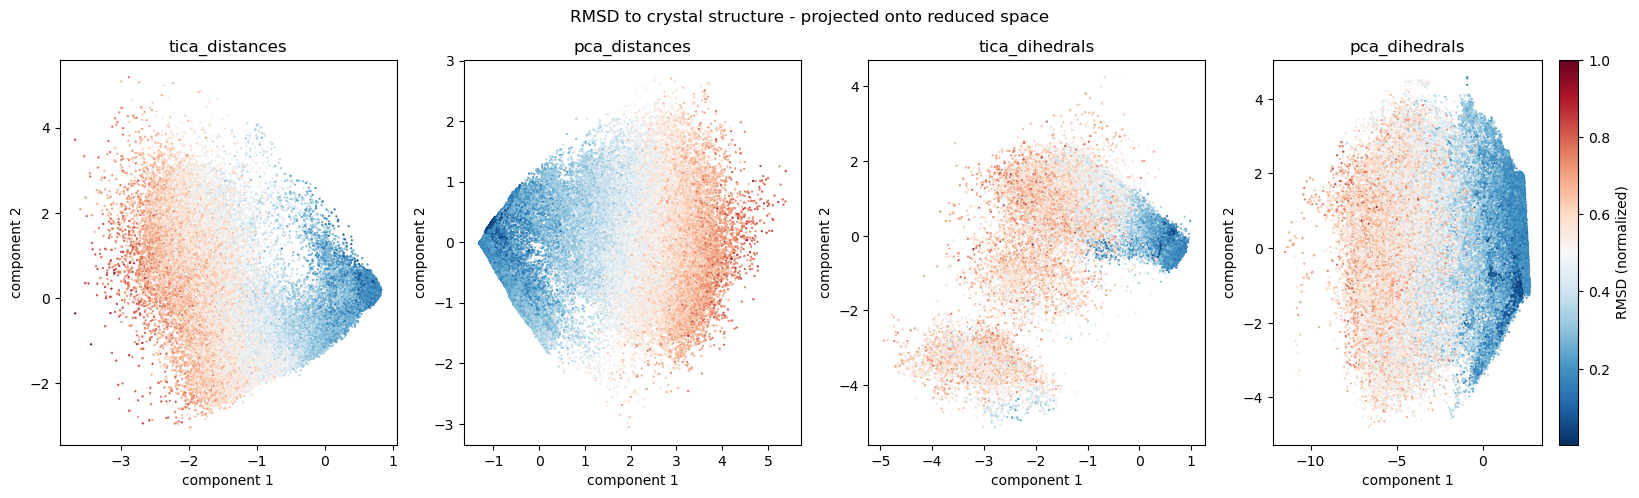

In [5]:
# Plot 1-Q for reference, and msm leading three eigenvectors
# (row stochastic convention -> look at the *right* eigenvectors)

# --------------------------------
# RMSD from crystal distances
# --------------------------------
crystal_dist = np.loadtxt(
    data_folder + "hp35.crystaldists",
    delimiter=" ",
    dtype=float
)

RMSD_timeseries = np.sqrt(np.mean(crystal_dist**2, axis=1))  # [nm]


z_timeseries = RMSD_timeseries - RMSD_timeseries.min()
z_timeseries = z_timeseries / z_timeseries.max() # now ranges from 0 to 1

fig, axs = plt.subplots(nrows = 1, ncols = 4, figsize=(20, 5))

for i, name in enumerate(trajectories_labels):
    ax = axs[i]
    ax.scatter(trajectories[i][:, 0][::10], trajectories[i][:, 1][::10], c = z_timeseries[::10], cmap = "RdBu_r", s=0.4, alpha=1)
    if i == len(trajectories_labels) - 1:
        plt.colorbar(ax.collections[0], ax=ax, label="RMSD (normalized)")
    #else:
    #    plt.colorbar(ax.collections[0], ax=ax)
    ax.set_xlabel("component 1")
    ax.set_ylabel("component 2")
    ax.set_title(f"{name}")

plt.suptitle(r"RMSD to crystal structure - projected onto reduced space")     
plt.show()

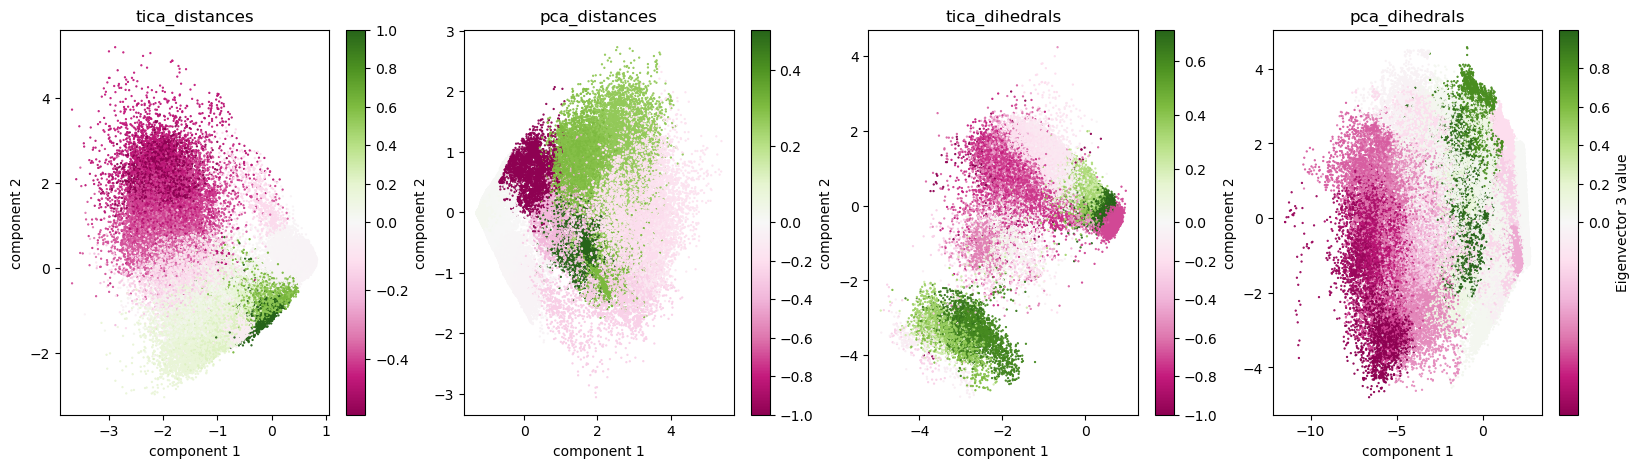

In [9]:
# Plotting the first eigenvector of the MSMs

mode_index = 3 # eigenvector index: 0 = stationary, 1 = slowest, 2 = second slowest

fig, axs = plt.subplots(
    nrows=1,
    ncols=4,
    figsize=(20, 5),
)


for i, name in enumerate(trajectories_labels):
    msm = msm_dict[name]

    # ---------------------------------------
    # Weighted dynamical mode: left eigenvector
    # ---------------------------------------
    #L = msm.eigenvectors_left(k=mode_index + 1)[mode_index, :]
    #L_normalized = L / np.max(np.abs(L))

    # ---------------------------------------
    # Unweighted dynamical mode: right eigenvector
    # ---------------------------------------
    R = msm.eigenvectors_right(k=mode_index + 1)[:, mode_index]
    R_normalized = R / np.max(np.abs(R))


    traj = micro_trajectory_dict[name]
    # transform  to eigvec values
    z_values = np.full((len(traj)), np.nan)
    mask = traj != -1
    z_values[mask] = R_normalized[traj[mask]]
    #z_values[mask] = L_normalized[traj[mask], :eigvecs_to_plot]

    xy = trajectories[i]

    ax = axs[i]
    norm = TwoSlopeNorm(vcenter=0.0)
    
    ax.scatter(xy[:, 0][::10], xy[:, 1][::10], c = z_values[::10], norm = norm, cmap = "PiYG", s=0.4, alpha=1)
    if i == len(trajectories_labels) - 1:
        plt.colorbar(ax.collections[0], ax=ax, label=f"Eigenvector {mode_index} value")
    else:
        plt.colorbar(ax.collections[0], ax=ax)
    ax.set_xlabel("component 1")
    ax.set_ylabel("component 2")
    ax.set_title(f"{name}")    

Plot the second eigenvector, only for the tICA models

---

## Report-quality versions of the same plots

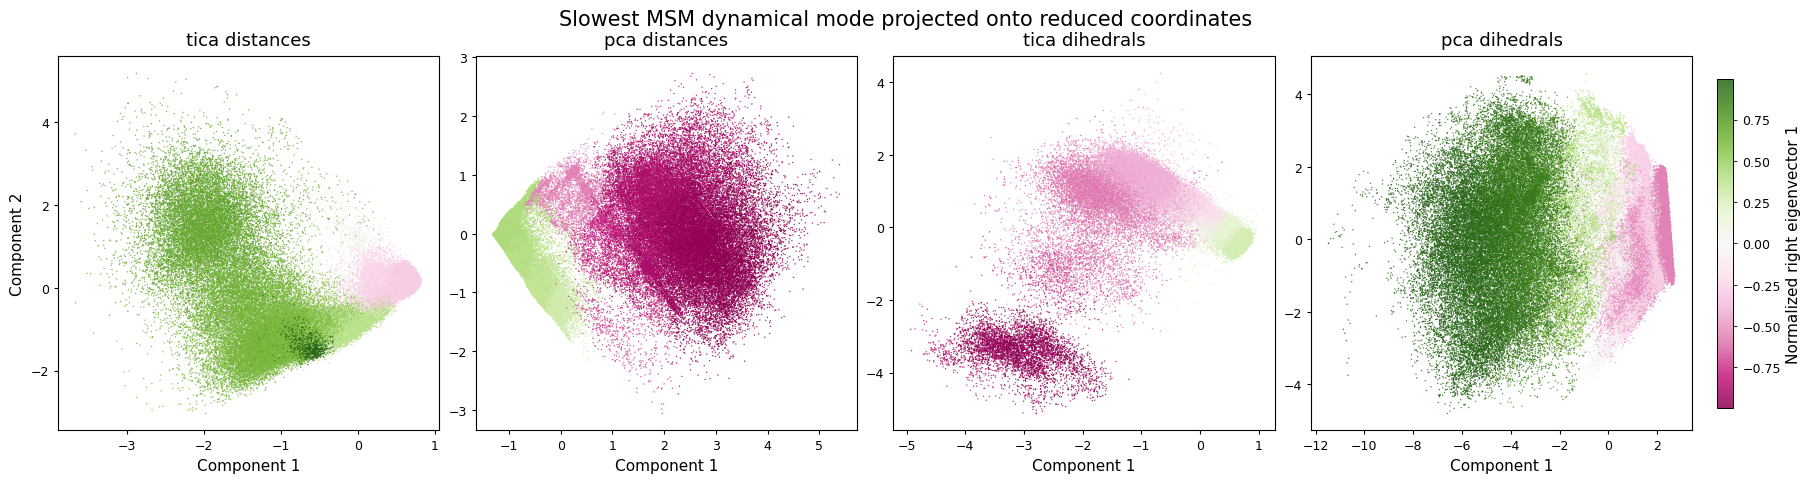

In [16]:
# -----------------------------
# Plotting the first non-stationary eigenvector of the MSMs
# -----------------------------

mode_index = 1   # 0 = stationary, 1 = slowest, 2 = second slowest
stride = 10

fig, axs = plt.subplots(
    nrows=1,
    ncols=4,
    figsize=(18, 4.5),
    sharex=False,
    sharey=False,
    constrained_layout=True,
)


# -----------------------------
# First pass: compute all z-values
# This allows a common color scale across all models.
# -----------------------------

z_values_dict = {}

for i, name in enumerate(trajectories_labels):
    msm = msm_dict[name]

    # ---------------------------------------
    # Unweighted dynamical mode: right eigenvector
    # ---------------------------------------
    R = msm.eigenvectors_right(k=mode_index + 1)[:, mode_index]
    R_normalized = R / np.max(np.abs(R))

    traj = micro_trajectory_dict[name]

    z_values = np.full(len(traj), np.nan)
    mask = traj != -1
    z_values[mask] = R_normalized[traj[mask]]

    z_values_dict[name] = z_values

# Common symmetric normalization
all_z = np.concatenate([
    z_values_dict[name][np.isfinite(z_values_dict[name])]
    for name in trajectories_labels
])

vmax = np.nanpercentile(np.abs(all_z), 99)
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

# -----------------------------
# Second pass: plot
# -----------------------------

for i, name in enumerate(trajectories_labels):
    ax = axs[i]

    xy = trajectories[i]
    z_values = z_values_dict[name]

    idx = np.arange(0, len(z_values), stride)
    finite = np.isfinite(z_values[idx])

    sc = ax.scatter(
        xy[idx, 0][finite],
        xy[idx, 1][finite],
        c=z_values[idx][finite],
        norm=norm,
        cmap="PiYG",
        s=1.0,
        alpha=0.85,
        linewidths=0,
        rasterized=True,
    )

    ax.set_title(
        name.replace("_", " "),
        fontsize=13,
        pad=8,
    )

    ax.set_xlabel("Component 1", fontsize=11)

    if i == 0:
        ax.set_ylabel("Component 2", fontsize=11)
    else:
        ax.set_ylabel("")

    ax.tick_params(
        axis="both",
        labelsize=9,
        direction="out",
        length=3,
        width=0.8,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)


# Shared colorbar
cbar = fig.colorbar(
    sc,
    ax=axs,
    location="right",
    shrink=0.88,
    pad=0.015,
)

cbar.set_label(
    f"Normalized right eigenvector {mode_index}",
    fontsize=11,
)
cbar.ax.tick_params(labelsize=9)

fig.suptitle(
    "Slowest MSM dynamical mode projected onto reduced coordinates",
    fontsize=15,
    y=1.04,
)

plt.savefig(
    f"../output_figures/msm_right_eigenvector_{mode_index}_projection.png",
    dpi=600,
    bbox_inches="tight",
)

plt.savefig(
    f"../output_figures/msm_right_eigenvector_{mode_index}_projection.pdf",
    bbox_inches="tight",
)
plt.show()

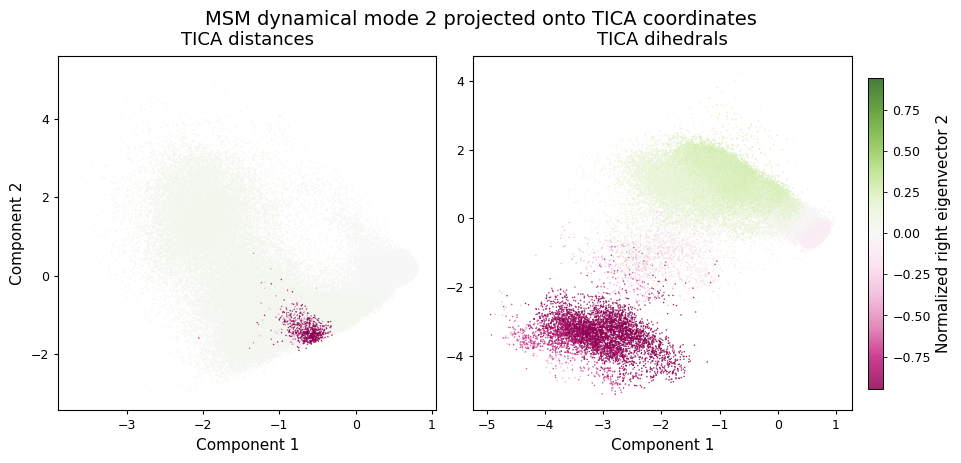

In [17]:
# -----------------------------
# Plotting the second non-stationary eigenvector of selected MSMs
# -----------------------------

mode_index = 2   # 0 = stationary, 1 = slowest, 2 = second slowest
stride = 10

trajectories_labels_for_plot = ["tica_distances", "tica_dihedrals"]
trajectories_for_plot = [tica_distances, tica_dihedrals]

pretty_labels = {
    "tica_distances": "TICA distances",
    "tica_dihedrals": "TICA dihedrals",
}

panel_labels = ["A", "B"]

fig, axs = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(9.5, 4.3),
    constrained_layout=True,
)

# -----------------------------
# First pass: compute z-values
# Needed for a common color scale.
# -----------------------------

z_values_dict = {}

for i, name in enumerate(trajectories_labels_for_plot):
    msm = msm_dict[name]

    # ---------------------------------------
    # Unweighted dynamical mode: right eigenvector
    # ---------------------------------------
    R = msm.eigenvectors_right(k=mode_index + 1)[:, mode_index]
    R_normalized = R / np.max(np.abs(R))

    traj = micro_trajectory_dict[name]

    z_values = np.full(len(traj), np.nan)
    mask = traj != -1
    z_values[mask] = R_normalized[traj[mask]]

    z_values_dict[name] = z_values

# Common symmetric normalization across both panels
all_z = np.concatenate([
    z_values_dict[name][np.isfinite(z_values_dict[name])]
    for name in trajectories_labels_for_plot
])

vmax = np.nanpercentile(np.abs(all_z), 99)
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

# -----------------------------
# Second pass: plot
# -----------------------------

for i, name in enumerate(trajectories_labels_for_plot):
    ax = axs[i]

    xy = trajectories_for_plot[i]
    z_values = z_values_dict[name]

    idx = np.arange(0, len(z_values), stride)
    finite = np.isfinite(z_values[idx])

    sc = ax.scatter(
        xy[idx, 0][finite],
        xy[idx, 1][finite],
        c=z_values[idx][finite],
        norm=norm,
        cmap="PiYG",
        s=1.2,
        alpha=0.85,
        linewidths=0,
        rasterized=True,
    )

    ax.set_title(
        pretty_labels.get(name, name.replace("_", " ")),
        fontsize=13,
        pad=8,
    )

    ax.set_xlabel("Component 1", fontsize=11)

    if i == 0:
        ax.set_ylabel("Component 2", fontsize=11)
    else:
        ax.set_ylabel("")

    ax.tick_params(
        axis="both",
        labelsize=9,
        direction="out",
        length=3,
        width=0.8,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)


# Shared colorbar
cbar = fig.colorbar(
    sc,
    ax=axs,
    location="right",
    shrink=0.88,
    pad=0.02,
)

cbar.set_label(
    f"Normalized right eigenvector {mode_index}",
    fontsize=11,
)
cbar.ax.tick_params(labelsize=9)

fig.suptitle(
    f"MSM dynamical mode {mode_index} projected onto TICA coordinates",
    fontsize=14,
    y=1.04,
)

plt.savefig(
    f"../output_figures/tica_right_eigenvector_{mode_index}_projection.png",
    dpi=600,
    bbox_inches="tight",
)

plt.savefig(
    f"../output_figures/tica_right_eigenvector_{mode_index}_projection.pdf",
    bbox_inches="tight",
)

plt.show()

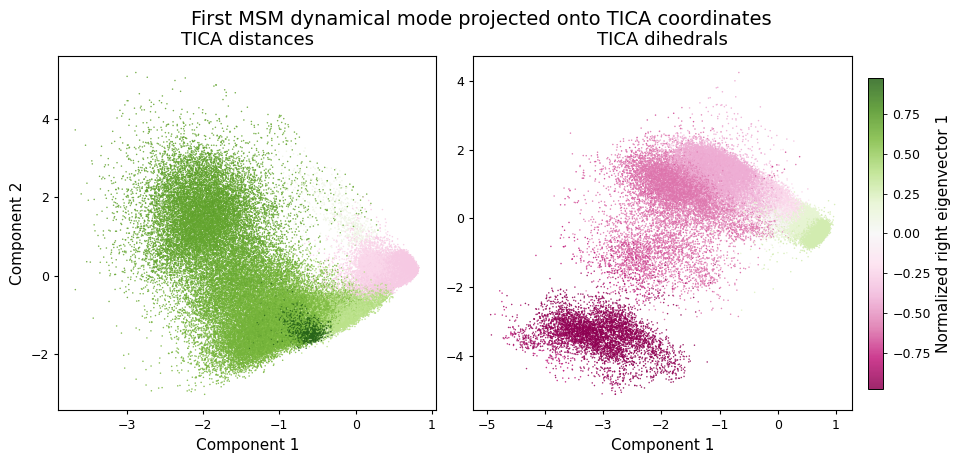

In [18]:
# -----------------------------
# Plotting the second non-stationary eigenvector of selected MSMs
# -----------------------------

mode_index = 1   # 0 = stationary, 1 = slowest, 2 = second slowest
stride = 10

trajectories_labels_for_plot = ["tica_distances", "tica_dihedrals"]
trajectories_for_plot = [tica_distances, tica_dihedrals]

pretty_labels = {
    "tica_distances": "TICA distances",
    "tica_dihedrals": "TICA dihedrals",
}

panel_labels = ["A", "B"]

fig, axs = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(9.5, 4.3),
    constrained_layout=True,
)

# -----------------------------
# First pass: compute z-values
# Needed for a common color scale.
# -----------------------------

z_values_dict = {}

for i, name in enumerate(trajectories_labels_for_plot):
    msm = msm_dict[name]

    # ---------------------------------------
    # Unweighted dynamical mode: right eigenvector
    # ---------------------------------------
    R = msm.eigenvectors_right(k=mode_index + 1)[:, mode_index]
    R_normalized = R / np.max(np.abs(R))

    traj = micro_trajectory_dict[name]

    z_values = np.full(len(traj), np.nan)
    mask = traj != -1
    z_values[mask] = R_normalized[traj[mask]]

    z_values_dict[name] = z_values

# Common symmetric normalization across both panels
all_z = np.concatenate([
    z_values_dict[name][np.isfinite(z_values_dict[name])]
    for name in trajectories_labels_for_plot
])

vmax = np.nanpercentile(np.abs(all_z), 99)
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

# -----------------------------
# Second pass: plot
# -----------------------------

for i, name in enumerate(trajectories_labels_for_plot):
    ax = axs[i]

    xy = trajectories_for_plot[i]
    z_values = z_values_dict[name]

    idx = np.arange(0, len(z_values), stride)
    finite = np.isfinite(z_values[idx])

    sc = ax.scatter(
        xy[idx, 0][finite],
        xy[idx, 1][finite],
        c=z_values[idx][finite],
        norm=norm,
        cmap="PiYG",
        s=1.2,
        alpha=0.85,
        linewidths=0,
        rasterized=True,
    )

    ax.set_title(
        pretty_labels.get(name, name.replace("_", " ")),
        fontsize=13,
        pad=8,
    )

    ax.set_xlabel("Component 1", fontsize=11)

    if i == 0:
        ax.set_ylabel("Component 2", fontsize=11)
    else:
        ax.set_ylabel("")

    ax.tick_params(
        axis="both",
        labelsize=9,
        direction="out",
        length=3,
        width=0.8,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)


# Shared colorbar
cbar = fig.colorbar(
    sc,
    ax=axs,
    location="right",
    shrink=0.88,
    pad=0.02,
)

cbar.set_label(
    f"Normalized right eigenvector {mode_index}",
    fontsize=11,
)
cbar.ax.tick_params(labelsize=9)

fig.suptitle(
    "First MSM dynamical mode projected onto TICA coordinates",
    fontsize=14,
    y=1.04,
)

plt.savefig(
    f"../output_figures/tica_right_eigenvector_{mode_index}_projection.png",
    dpi=600,
    bbox_inches="tight",
)

plt.savefig(
    f"../output_figures/tica_right_eigenvector_{mode_index}_projection.pdf",
    bbox_inches="tight",
)

plt.show()